<a href="https://colab.research.google.com/github/msemihyasa/Semih/blob/main/DD%C4%B0_Final_244329037.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Kütüphanelerin Yüklenmesi

In [1]:
!pip install nltk pandas scikit-learn matplotlib seaborn
!pip install optuna
import pandas as pd
import numpy as np
import nltk
import os # dosya işlemleri
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import re # regex

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from collections import Counter

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import LinearSVC

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Kullanılan cihaz: {DEVICE}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 7.9 MB/s eta 0:00:00
Kullanılan cihaz: cuda


## 2. Veri Yükleme

In [2]:
import kagglehub

path = kagglehub.dataset_download("metinhsimimi/hepsiburada-300k-reviews-from-hf")

print("@dataset{alibayram2024hepsiburada_yorumlari, \nurl = https://huggingface.co/datasets/alibayram/hepsiburada_yorumlar, \nlicense = {Creative Commons Attribution Non Commercial 4.0}")
print("Path to dataset files:", path)

100%|██████████| 20.1M/20.1M [00:00<00:00, 133MB/s]

Extracting files...


@dataset{alibayram2024hepsiburada_yorumlari, 
url = https://huggingface.co/datasets/alibayram/hepsiburada_yorumlar, 
license = {Creative Commons Attribution Non Commercial 4.0}
Path to dataset files: /root/.cache/kagglehub/datasets/metinhsimimi/hepsiburada-300k-reviews-from-hf/versions/1


### 2.1. Veri Analizi

In [3]:
csv_file_path = os.path.join(path, 'hepsiburada_balanced_300k.csv')
df = pd.read_csv(csv_file_path)

print(f"Toplam Satır: {len(df)}")
print("Sınıf Dağılımı:")
display(df['label'].value_counts())     # sınıf:    0 = negatif, 1 = nötr, and 2 = pozitif
print('=== Veri Tipleri ===')
print(df.dtypes)
print()
display(df.head())

Toplam Satır: 300000
Sınıf Dağılımı:


,count
label,
0,100000
1,100000
2,100000


=== Veri Tipleri ===
combined_text    object
label             int64
dtype: object



,combined_text,label
0,İki Yıldız. iyi,0
1,Bir Yıldız. kargo sorunsuz geldi ama tam 1 haf...,0
2,Kokusu dışında iş görür. Çok fazla koku yapıyo...,0
3,kötü. saat içinden çıkıyor beklediğim gibi kal...,0
4,Çok kötü.... Almayın çok kötü boşa para verirs...,0


## 3. Text Preprocessing

In [4]:
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)

turkish_stopwords = set(stopwords.words('turkish'))

def base_clean(text):
    # ML ve DL için ortak temizlik adımları
    text = str(text).lower()                    # küçük harf
    text = re.sub(r'[^\w\s]', '', text)         # noktalama
    text = re.sub(r'\d+', '', text)             # sayılar
    text = re.sub(r'\s+', ' ', text).strip()    # fazla boşluk
    return text

def preprocess_for_ml(text):
    # TF-IDF + NB/SVM: stopword kaldırılır, word_tokenize kullanılır
    text = base_clean(text)
    tokens = word_tokenize(text, language='turkish')
    tokens = [t for t in tokens if t not in turkish_stopwords]
    return " ".join(tokens)

def preprocess_for_dl(text):
    # BiLSTM: stopword korunur, kelime sırası ve bağlam bozulmaz. LSTM kelime sırasından bağlamı öğrenir.
    # Ör: "çok iyi değil" → stopword kaldırılırsa "iyi" kalır, anlam değişir
    return base_clean(text)

df['text_ml'] = df['combined_text'].apply(preprocess_for_ml)
df['text_dl'] = df['combined_text'].apply(preprocess_for_dl)

print("Metin temizleme tamamlandı.")
display(df.head())

Metin temizleme tamamlandı.


,combined_text,label,text_ml,text_dl
0,İki Yıldız. iyi,0,iki yıldız iyi,iki yıldız iyi
1,Bir Yıldız. kargo sorunsuz geldi ama tam 1 haf...,0,bir yıldız kargo sorunsuz geldi tam haftada ko...,bir yıldız kargo sorunsuz geldi ama tam haftad...
2,Kokusu dışında iş görür. Çok fazla koku yapıyo...,0,kokusu dışında iş görür fazla koku yapıyor kut...,kokusu dışında iş görür çok fazla koku yapıyor...
3,kötü. saat içinden çıkıyor beklediğim gibi kal...,0,kötü saat içinden çıkıyor beklediğim kaliteli ...,kötü saat içinden çıkıyor beklediğim gibi kali...
4,Çok kötü.... Almayın çok kötü boşa para verirs...,0,kötü almayın kötü boşa para verirsiniz isınmıy...,çok kötü almayın çok kötü boşa para verirsiniz...


## 4. Veri Setini Bölme


In [5]:
# Test seti tüm senaryolar için sabit kalacak şekilde dengeli 300k üzerinden ayrılıyor
X_temp_ml, X_test_ml, \
X_temp_dl, X_test_dl, \
y_temp, y_test = train_test_split(
    df['text_ml'], df['text_dl'], df['label'],
    test_size=0.10, random_state=42, stratify=df['label'] # stratify: her sınıfın oranı train/val/test'te korunuyor
)

# Kalan %90 -> Train %80 ve Validation %10
X_train_ml, X_val_ml, \
X_train_dl, X_val_dl, \
y_train, y_val = train_test_split(
    X_temp_ml, X_temp_dl, y_temp,
    test_size=0.111, random_state=42, stratify=y_temp
)

print(f"Veri Seti Bölünmesi = Train: {len(X_train_ml)}, Val: {len(X_val_ml)}, Test: {len(X_test_ml)}")
print(f"Test sınıf dağılımı:\n{y_test.value_counts().sort_index()}")

Veri Seti Bölünmesi = Train: 240030, Val: 29970, Test: 30000
Test sınıf dağılımı:
label
0    10000
1    10000
2    10000
Name: count, dtype: int64


## 5. Veri Senaryolarının Oluşturulması

In [6]:
# Senaryo tanımları: train setinden seçilecek örnek sayıları
# label: 0 = negatif, 1 = nötr, 2 = pozitif
SCENARIOS = {
    'S1': {0: 80000, 1: 80000, 2: 80000},
    'S2': {0: 64000, 1: 16000, 2: 80000},
    'S3': {0: 24000, 1:  4000, 2: 80000},
    'S4': {0: 16000, 1: 56000, 2: 80000},
}

def create_scenario(X_ml, X_dl, y, scenario_counts, random_state=42):
    # Her sınıftan belirlenen sayıda örnek train setinden seçilir
    selected_idx = []
    for label, n in scenario_counts.items():
        class_idx = y[y == label].index.tolist()
        sampled = pd.Series(class_idx).sample(n=n, random_state=random_state).tolist()
        selected_idx.extend(sampled)

    X_ml_out = X_ml.loc[selected_idx]
    X_dl_out = X_dl.loc[selected_idx]
    y_out    = y.loc[selected_idx]

    return X_ml_out, X_dl_out, y_out

# Her senaryo için sadece train seti üzerinden seçim yapılıyor
# Val ve Test setleri sabit, senaryoya dahil edilmiyor
scenario_data = {}
for name, counts in SCENARIOS.items():
    X_sc_ml, X_sc_dl, y_sc = create_scenario(
        X_train_ml, X_train_dl, y_train, counts
    )

    # Senaryo train seti içinde tekrar train/val bölünmesi
    X_sc_train_ml, X_sc_val_ml, \
    X_sc_train_dl, X_sc_val_dl, \
    y_sc_train, y_sc_val = train_test_split(
        X_sc_ml, X_sc_dl, y_sc,
        test_size=0.111, random_state=42, stratify=y_sc
    )

    scenario_data[name] = {
        'X_train_ml': X_sc_train_ml, 'X_val_ml': X_sc_val_ml,
        'X_train_dl': X_sc_train_dl, 'X_val_dl': X_sc_val_dl,
        'y_train':    y_sc_train,    'y_val':    y_sc_val
    }

    print(f"{name} | Train: {len(y_sc_train)}, Val: {len(y_sc_val)}")
    print(f"     Sınıf dağılımı (train): {dict(y_sc_train.value_counts().sort_index())}")

S1 | Train: 213360, Val: 26640
     Sınıf dağılımı (train): {0: np.int64(71120), 1: np.int64(71120), 2: np.int64(71120)}
S2 | Train: 142240, Val: 17760
     Sınıf dağılımı (train): {0: np.int64(56896), 1: np.int64(14224), 2: np.int64(71120)}
S3 | Train: 96012, Val: 11988
     Sınıf dağılımı (train): {0: np.int64(21336), 1: np.int64(3556), 2: np.int64(71120)}
S4 | Train: 135128, Val: 16872
     Sınıf dağılımı (train): {0: np.int64(14224), 1: np.int64(49784), 2: np.int64(71120)}


## 6. ML Pipeline

### 6.1 Feature Extraction ve Feature Selection

In [7]:
def build_features(X_train_ml, X_val_ml, y_train, k_features=20000):
    # TF-IDF: unigram ve bigram, veri sızıntısını önlemek için sadece train'e fit ediliyor
    tfidf = TfidfVectorizer(ngram_range=(1, 2), max_features=50000)
    X_train_tfidf = tfidf.fit_transform(X_train_ml)
    X_val_tfidf   = tfidf.transform(X_val_ml)
    X_test_tfidf  = tfidf.transform(X_test_ml)

    # Chi-Square ile öznitelik seçimi: sadece train üzerinde fit ediliyor
    selector = SelectKBest(chi2, k=k_features)
    X_train_sel = selector.fit_transform(X_train_tfidf, y_train)
    X_val_sel   = selector.transform(X_val_tfidf)
    X_test_sel  = selector.transform(X_test_tfidf)

    return X_train_sel, X_val_sel, X_test_sel, tfidf, selector

print("build_features tanımlandı.")

build_features tanımlandı.


### 6.2 Naive Bayes

In [8]:
def run_nb(X_train, X_val, X_test, y_train, y_val, scenario_name):
    # Hyperparameter tuning: alpha grid, validation seti üzerinde
    best_alpha, best_score = 0, 0
    for a in [0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]:
        model = MultinomialNB(alpha=a)
        model.fit(X_train, y_train)
        score = accuracy_score(y_val, model.predict(X_val))
        if score > best_score:
            best_score = score
            best_alpha = a

    # En iyi alpha ile yeniden eğitim
    nb_model = MultinomialNB(alpha=best_alpha)
    nb_model.fit(X_train, y_train)

    # Test seti tahmini
    y_pred = nb_model.predict(X_test)

    print(f"\n--- {scenario_name} | NB TEST SETİ PERFORMANSI ---")
    print(f"En iyi Alpha: {best_alpha}")
    print(classification_report(y_test, y_pred, target_names=["Negatif", "Nötr", "Pozitif"]))

    plt.figure(figsize=(8, 6))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
                xticklabels=["Negatif", "Nötr", "Pozitif"],
                yticklabels=["Negatif", "Nötr", "Pozitif"])
    plt.xlabel('Tahmin Edilen Sınıf')
    plt.ylabel('Gerçek Sınıf')
    plt.title(f'NB Confusion Matrix — {scenario_name}')
    plt.tight_layout()
    plt.show()

    return nb_model, y_pred

print("run_nb tanımlandı.")

run_nb tanımlandı.


### 6.3 SVM

In [9]:
def run_svm(X_train, X_val, X_test, y_train, y_val, scenario_name):
    # Hyperparameter tuning: C grid, validation seti üzerinde
    best_c, best_score = 0, 0
    for c_val in [0.01, 0.1, 0.5, 1.0, 5.0]:
        model = LinearSVC(C=c_val, random_state=42, dual=False)
        model.fit(X_train, y_train)
        score = accuracy_score(y_val, model.predict(X_val))
        if score > best_score:
            best_score = score
            best_c = c_val

    # En iyi C ile yeniden eğitim
    svm_model = LinearSVC(C=best_c, random_state=42, dual=False)
    svm_model.fit(X_train, y_train)

    # Test seti tahmini
    y_pred = svm_model.predict(X_test)

    print(f"\n--- {scenario_name} | SVM TEST SETİ PERFORMANSI ---")
    print(f"En iyi C: {best_c}")
    print(classification_report(y_test, y_pred, target_names=["Negatif", "Nötr", "Pozitif"]))

    plt.figure(figsize=(8, 6))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Oranges',
                xticklabels=["Negatif", "Nötr", "Pozitif"],
                yticklabels=["Negatif", "Nötr", "Pozitif"])
    plt.xlabel('Tahmin Edilen Sınıf')
    plt.ylabel('Gerçek Sınıf')
    plt.title(f'SVM Confusion Matrix — {scenario_name}')
    plt.tight_layout()
    plt.show()

    return svm_model, y_pred

print("run_svm tanımlandı.")

run_svm tanımlandı.


### 6.4 Senaryoları Çalıştırma


SENARYO: S1

--- S1 | NB TEST SETİ PERFORMANSI ---
En iyi Alpha: 10.0
              precision    recall  f1-score   support

     Negatif       0.83      0.82      0.82     10000
        Nötr       0.66      0.66      0.66     10000
     Pozitif       0.79      0.80      0.79     10000

    accuracy                           0.76     30000
   macro avg       0.76      0.76      0.76     30000
weighted avg       0.76      0.76      0.76     30000



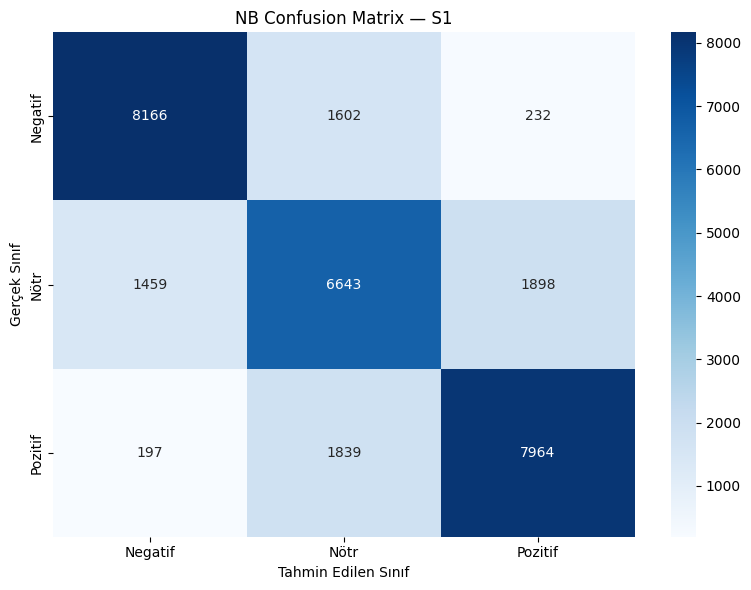


--- S1 | SVM TEST SETİ PERFORMANSI ---
En iyi C: 0.1
              precision    recall  f1-score   support

     Negatif       0.82      0.87      0.84     10000
        Nötr       0.70      0.66      0.68     10000
     Pozitif       0.81      0.81      0.81     10000

    accuracy                           0.78     30000
   macro avg       0.78      0.78      0.78     30000
weighted avg       0.78      0.78      0.78     30000



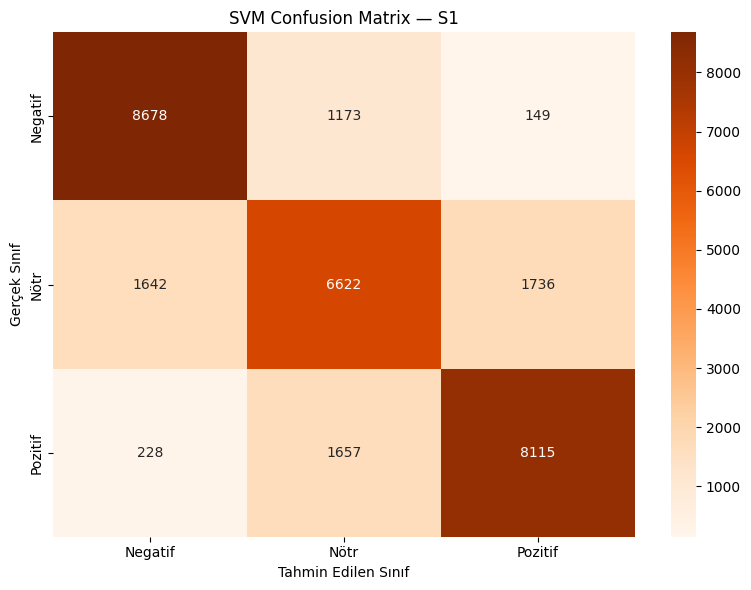


SENARYO: S2

--- S2 | NB TEST SETİ PERFORMANSI ---
En iyi Alpha: 0.5
              precision    recall  f1-score   support

     Negatif       0.68      0.94      0.79     10000
        Nötr       0.92      0.21      0.34     10000
     Pozitif       0.67      0.93      0.78     10000

    accuracy                           0.69     30000
   macro avg       0.76      0.69      0.64     30000
weighted avg       0.76      0.69      0.64     30000



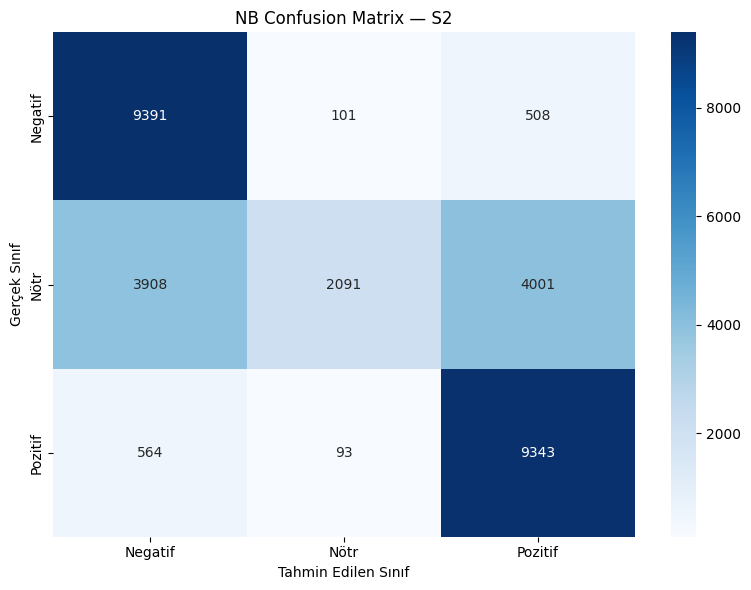


--- S2 | SVM TEST SETİ PERFORMANSI ---
En iyi C: 0.5
              precision    recall  f1-score   support

     Negatif       0.72      0.95      0.82     10000
        Nötr       0.94      0.27      0.43     10000
     Pozitif       0.68      0.95      0.79     10000

    accuracy                           0.73     30000
   macro avg       0.78      0.73      0.68     30000
weighted avg       0.78      0.73      0.68     30000



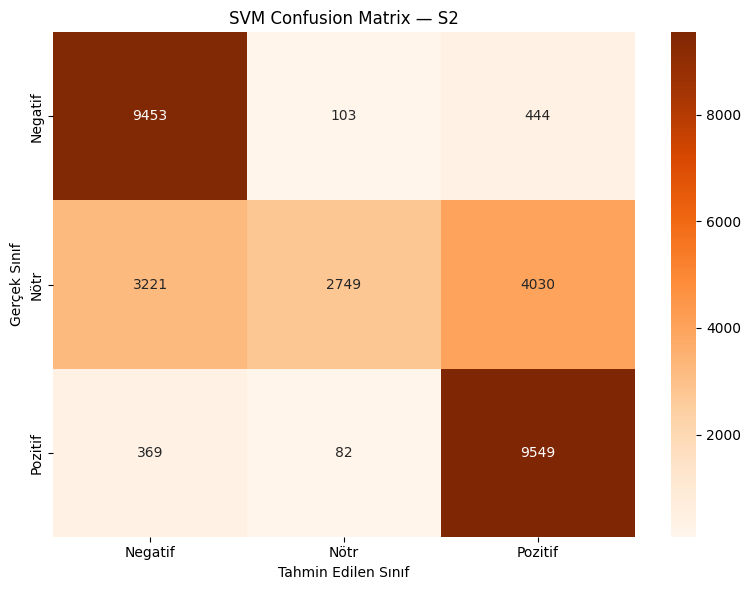


SENARYO: S3

--- S3 | NB TEST SETİ PERFORMANSI ---
En iyi Alpha: 0.01
              precision    recall  f1-score   support

     Negatif       0.73      0.87      0.79     10000
        Nötr       0.96      0.16      0.27     10000
     Pozitif       0.59      0.97      0.74     10000

    accuracy                           0.67     30000
   macro avg       0.76      0.67      0.60     30000
weighted avg       0.76      0.67      0.60     30000



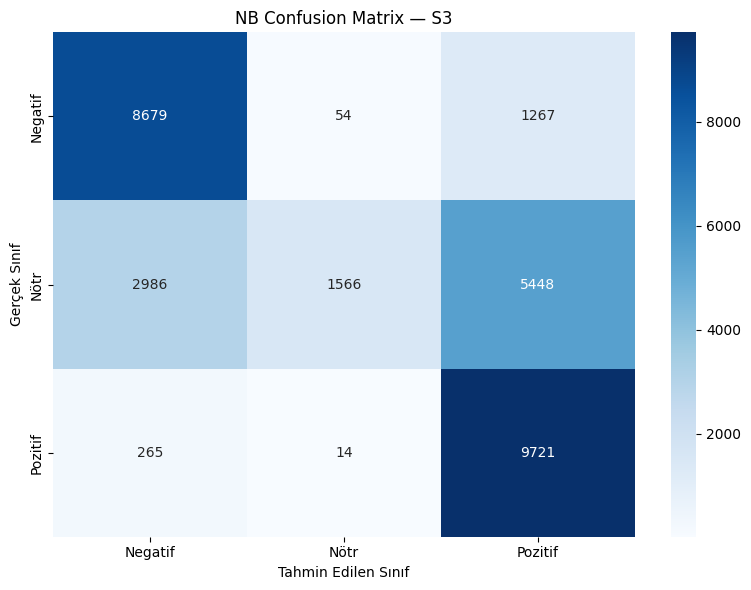


--- S3 | SVM TEST SETİ PERFORMANSI ---
En iyi C: 0.5
              precision    recall  f1-score   support

     Negatif       0.77      0.89      0.83     10000
        Nötr       0.99      0.22      0.36     10000
     Pozitif       0.61      0.98      0.75     10000

    accuracy                           0.70     30000
   macro avg       0.79      0.70      0.65     30000
weighted avg       0.79      0.70      0.65     30000



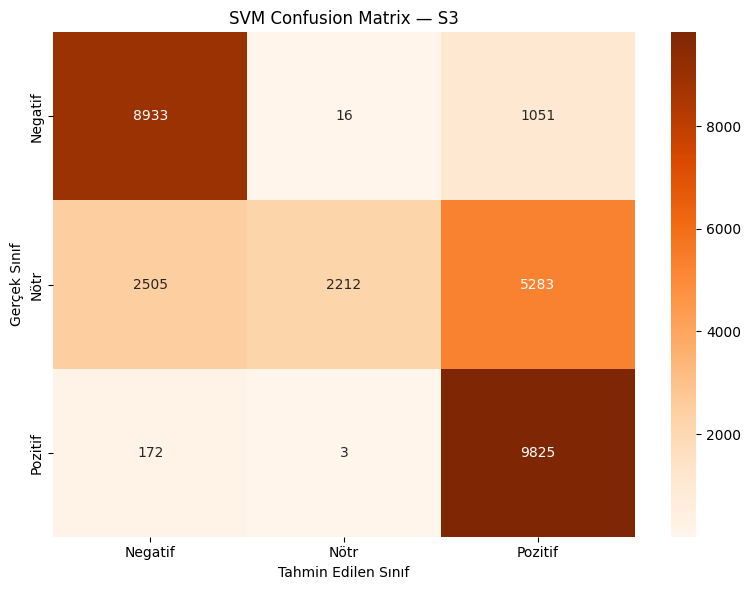


SENARYO: S4

--- S4 | NB TEST SETİ PERFORMANSI ---
En iyi Alpha: 0.5
              precision    recall  f1-score   support

     Negatif       0.95      0.46      0.62     10000
        Nötr       0.53      0.72      0.61     10000
     Pozitif       0.74      0.84      0.79     10000

    accuracy                           0.68     30000
   macro avg       0.74      0.68      0.67     30000
weighted avg       0.74      0.68      0.67     30000



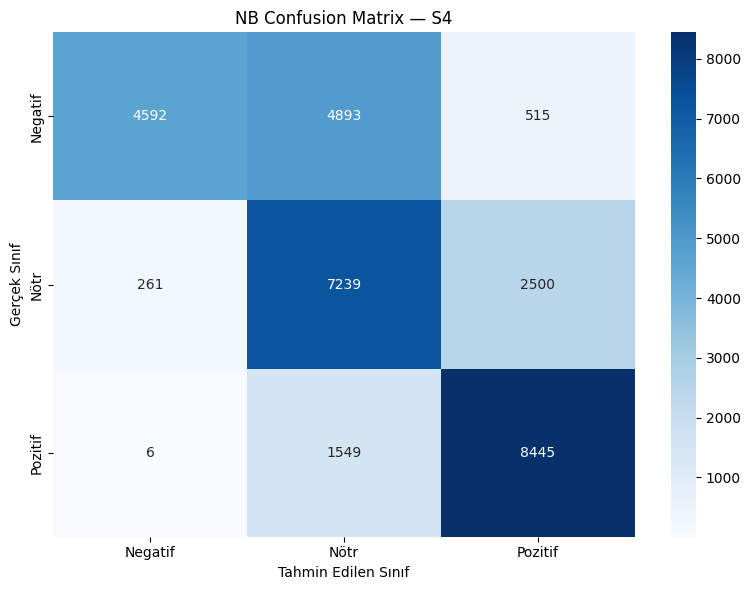


--- S4 | SVM TEST SETİ PERFORMANSI ---
En iyi C: 0.1
              precision    recall  f1-score   support

     Negatif       0.94      0.56      0.70     10000
        Nötr       0.58      0.72      0.64     10000
     Pozitif       0.75      0.88      0.81     10000

    accuracy                           0.72     30000
   macro avg       0.76      0.72      0.72     30000
weighted avg       0.76      0.72      0.72     30000



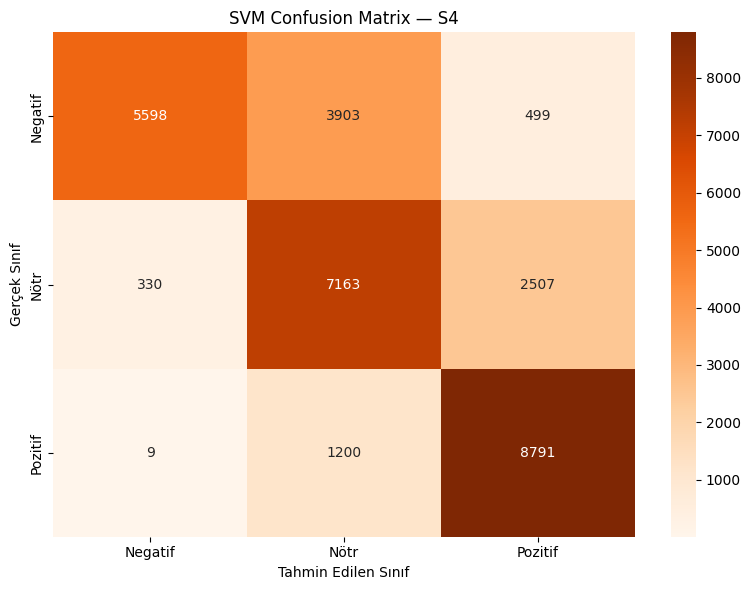

In [10]:
ml_results = {}

for name, data in scenario_data.items():
    print(f"\n{'='*50}")
    print(f"SENARYO: {name}")
    print(f"{'='*50}")

    # Feature extraction ve selection
    X_train_sel, X_val_sel, X_test_sel, tfidf, selector = build_features(
        data['X_train_ml'], data['X_val_ml'], data['y_train'], k_features=20000
    )

    # NB
    nb_model, nb_preds = run_nb(
        X_train_sel, X_val_sel, X_test_sel,
        data['y_train'], data['y_val'], name
    )

    # SVM
    svm_model, svm_preds = run_svm(
        X_train_sel, X_val_sel, X_test_sel,
        data['y_train'], data['y_val'], name
    )

    ml_results[name] = {
        'nb_model':  nb_model,
        'nb_preds':  nb_preds,
        'svm_model': svm_model,
        'svm_preds': svm_preds,
    }

## 7. DL Pipeline

### 7.1 Tokenization ve Padding

In [11]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Kullanılan cihaz: {DEVICE}")

MAX_WORDS = 50000  # Kelime kütüphanesi boyutu
MAX_LEN   = 100    # Maksimum token sayısı

def build_vocab(X_train_dl):
    # Kelime sayımı veri sızıntısını önlemek için sadece train seti üzerinde yapılıyor
    counter = Counter()
    for text in X_train_dl:
        counter.update(text.split())

    # <PAD> dolgu, <UNK> bilinmeyen kelime
    vocab = {'<PAD>': 0, '<UNK>': 1}
    for word, _ in counter.most_common(MAX_WORDS - 2):
        vocab[word] = len(vocab)

    print(f"Kelime kütüphanesi boyutu: {len(vocab)}")
    return vocab

def encode(text, vocab):
    # Metni token ID listesine çevirir, MAX_LEN'e göre kırpar veya doldurur
    ids = [vocab.get(w, 1) for w in text.split()]  # bilinmeyen -> <UNK>=1
    ids = ids[:MAX_LEN]                             # 100'den fazla ise kırpma
    ids += [0] * (MAX_LEN - len(ids))              # doldur (<PAD>=0)
    return ids

print("build_vocab ve encode fonksiyonları tanımlandı.")

Kullanılan cihaz: cuda
build_vocab ve encode fonksiyonları tanımlandı.


### 7.2 Dataset

In [12]:
class SentimentDataset(Dataset):
    def __init__(self, texts, labels, vocab):
        self.X = [torch.tensor(encode(t, vocab), dtype=torch.long) for t in texts]
        self.y = torch.tensor(labels.values, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

print("Sentiment Dataset tanımlandı.")

Sentiment Dataset tanımlandı.


### 7.3 Model Mimarisi

In [13]:
class SentimentRNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, num_classes, dropout):
        super().__init__()
        # <PAD>=0 token'ı embedding'de sıfır vektör olarak tutulur
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,                          # her iki yönden bağlamı yakalar
            dropout=dropout if num_layers > 1 else 0
        )
        self.dropout = nn.Dropout(dropout)
        # Bidirectional olduğu için hidden_dim * 2
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x):
        embedded = self.dropout(self.embedding(x))       # (batch, seq, embed)
        output, (hidden, _) = self.lstm(embedded)
        # Son katmanın iki yönlü hidden state'lerini birleştir
        hidden_fwd = hidden[-2]                          # ileri yön, son katman
        hidden_bwd = hidden[-1]                          # geri yön, son katman
        combined = torch.cat([hidden_fwd, hidden_bwd], dim=1)
        return self.fc(self.dropout(combined))           # (batch, num_classes)

print("Sentiment RNN tanımlandı.")

Sentiment RNN tanımlandı.


### 7.4 Optuna ile Hiperparametre Optimizasyonu

In [15]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

BATCH_SIZE = 256
EPOCHS     = 5   # Optuna trial başına maksimum epoch
PATIENCE   = 3

def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # gradient boosting önler
        optimizer.step()
        total_loss += loss.item() * len(y_batch)
        correct += (logits.argmax(1) == y_batch).sum().item()
        total += len(y_batch)
    return total_loss / total, correct / total

def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            total_loss += loss.item() * len(y_batch)
            correct += (logits.argmax(1) == y_batch).sum().item()
            total += len(y_batch)
    return total_loss / total, correct / total

def objective(trial, train_loader, val_loader, vocab_size):
    # Optuna'nın arayacağı hiperparametreler
    embed_dim  = trial.suggest_categorical('embed_dim',  [64, 128, 256])
    hidden_dim = trial.suggest_categorical('hidden_dim', [64, 128, 256])
    num_layers = trial.suggest_int('num_layers', 1, 2)
    dropout    = trial.suggest_float('dropout', 0.1, 0.5)
    lr         = trial.suggest_float('lr', 1e-4, 1e-2, log=True)

    model = SentimentRNN(
        vocab_size=vocab_size,
        embed_dim=embed_dim,
        hidden_dim=hidden_dim,
        num_layers=num_layers,
        num_classes=3,
        dropout=dropout
    ).to(DEVICE)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    best_val_loss  = float('inf')
    patience_count = 0

    for epoch in range(1, EPOCHS + 1):
        train_epoch(model, train_loader, optimizer, criterion)
        val_loss, _ = eval_epoch(model, val_loader, criterion)

        if val_loss < best_val_loss:
            best_val_loss  = val_loss
            patience_count = 0
        else:
            patience_count += 1
            if patience_count >= PATIENCE:
                break

    return best_val_loss

# Optuna sadece S1 (baseline) üzerinde çalıştırılıyor
# Bulunan hiperparametreler tüm senaryolara uygulanacak
print("S1 üzerinde Optuna optimizasyonu başlıyor (15 trial)")

s1_data  = scenario_data['S1']
s1_vocab = build_vocab(s1_data['X_train_dl'])

s1_train_dataset = SentimentDataset(s1_data['X_train_dl'], s1_data['y_train'], s1_vocab)
s1_val_dataset   = SentimentDataset(s1_data['X_val_dl'],   s1_data['y_val'],   s1_vocab)
s1_train_loader  = DataLoader(s1_train_dataset, batch_size=BATCH_SIZE, shuffle=True)
s1_val_loader    = DataLoader(s1_val_dataset,   batch_size=BATCH_SIZE)

study = optuna.create_study(direction='minimize')
study.optimize(
    lambda trial: objective(trial, s1_train_loader, s1_val_loader, len(s1_vocab)),
    n_trials=15
)

best_params = study.best_params
print(f"\nOptuna tamamlandı.")
print(f"En iyi hiperparametreler: {best_params}")

S1 üzerinde Optuna optimizasyonu başlıyor (15 trial)
Kelime kütüphanesi boyutu: 50000

Optuna tamamlandı.
En iyi hiperparametreler: {'embed_dim': 256, 'hidden_dim': 256, 'num_layers': 1, 'dropout': 0.1292115119708336, 'lr': 0.0008464595038339298}


### 7.5 Bi-LSTM Eğitimi

In [16]:
def run_lstm(X_train_dl, X_val_dl, y_train, y_val, best_params, scenario_name):
    # Vocab sadece train seti üzerinden oluşturuluyor
    vocab = build_vocab(X_train_dl)

    train_dataset = SentimentDataset(X_train_dl, y_train, vocab)
    val_dataset   = SentimentDataset(X_val_dl,   y_val,   vocab)
    test_dataset  = SentimentDataset(X_test_dl,  y_test,  vocab)

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE)
    test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE)

    model = SentimentRNN(
        vocab_size=len(vocab),
        embed_dim=best_params['embed_dim'],
        hidden_dim=best_params['hidden_dim'],
        num_layers=best_params['num_layers'],
        num_classes=3,
        dropout=best_params['dropout']
    ).to(DEVICE)

    optimizer = torch.optim.Adam(model.parameters(), lr=best_params['lr'])
    criterion = nn.CrossEntropyLoss()

    best_val_loss  = float('inf')
    patience_count = 0
    best_state     = None
    history        = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(1, 21):
        train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion)
        val_loss,   val_acc   = eval_epoch(model, val_loader,   criterion)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(f"Epoch {epoch:2d} | Train Loss: {train_loss:.4f}  Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f}  Acc: {val_acc:.4f}")

        # EarlyStop
        if val_loss < best_val_loss:
            best_val_loss  = val_loss
            patience_count = 0
            best_state     = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            patience_count += 1
            if patience_count >= PATIENCE:
                print(f"EarlyStopping: {epoch}. epoch'ta durduruldu.")
                break

    model.load_state_dict(best_state)
    print("En iyi model yüklendi.")

    # Eğitim grafiği
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(history['train_acc'], label='Train')
    axes[0].plot(history['val_acc'],   label='Validation')
    axes[0].set_title(f'LSTM Accuracy — {scenario_name}')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()

    axes[1].plot(history['train_loss'], label='Train')
    axes[1].plot(history['val_loss'],   label='Validation')
    axes[1].set_title(f'LSTM Loss — {scenario_name}')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    # Test seti tahmini
    model.eval()
    all_preds = []
    with torch.no_grad():
        for X_batch, _ in test_loader:
            logits = model(X_batch.to(DEVICE))
            all_preds.extend(logits.argmax(1).cpu().numpy())

    y_pred = np.array(all_preds)

    print(f"\n--- {scenario_name} | LSTM TEST SETİ PERFORMANSI ---")
    print(classification_report(y_test, y_pred, target_names=["Negatif", "Nötr", "Pozitif"]))

    plt.figure(figsize=(8, 6))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
                xticklabels=["Negatif", "Nötr", "Pozitif"],
                yticklabels=["Negatif", "Nötr", "Pozitif"])
    plt.xlabel('Tahmin Edilen Sınıf')
    plt.ylabel('Gerçek Sınıf')
    plt.title(f'LSTM Confusion Matrix — {scenario_name}')
    plt.tight_layout()
    plt.show()

    return model, y_pred

print("run_lstm fonksiyonu tanımlandı.")

run_lstm fonksiyonu tanımlandı.


### 7.6 Senaryoları Çalıştırma


SENARYO: S1
Kelime kütüphanesi boyutu: 50000
Epoch  1 | Train Loss: 0.5527  Acc: 0.7405 | Val Loss: 0.4802  Acc: 0.7784
Epoch  2 | Train Loss: 0.4615  Acc: 0.7887 | Val Loss: 0.4753  Acc: 0.7817
Epoch  3 | Train Loss: 0.4125  Acc: 0.8153 | Val Loss: 0.4523  Acc: 0.7960
Epoch  4 | Train Loss: 0.3659  Acc: 0.8397 | Val Loss: 0.4695  Acc: 0.7968
Epoch  5 | Train Loss: 0.3177  Acc: 0.8642 | Val Loss: 0.4787  Acc: 0.7983
Epoch  6 | Train Loss: 0.2774  Acc: 0.8839 | Val Loss: 0.5093  Acc: 0.7983
EarlyStopping: 6. epoch'ta durduruldu.
En iyi model yüklendi.


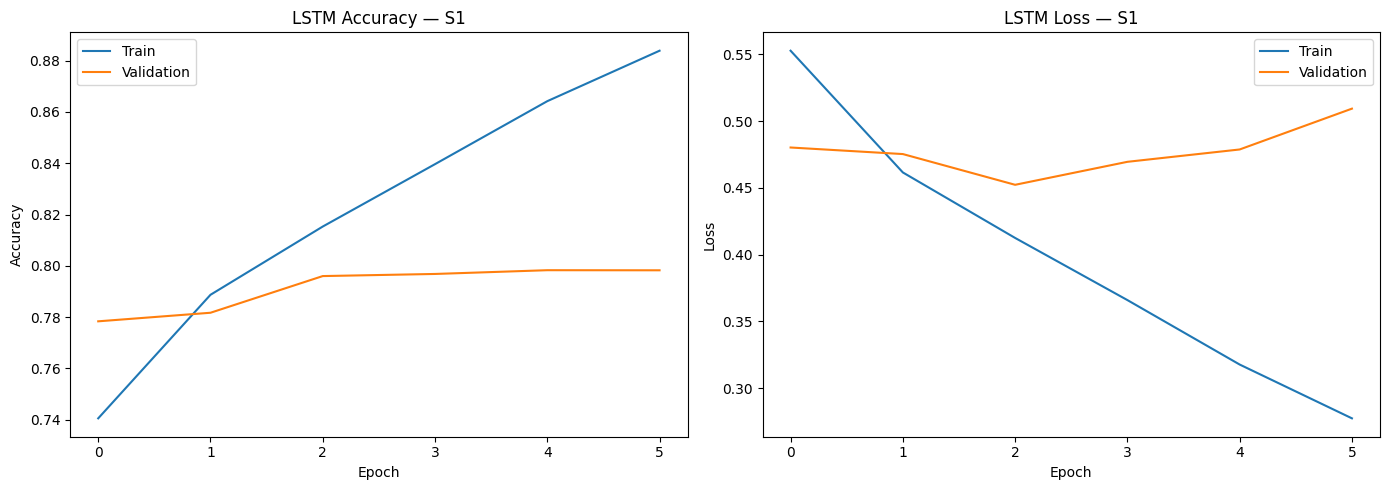


--- S1 | LSTM TEST SETİ PERFORMANSI ---
              precision    recall  f1-score   support

     Negatif       0.84      0.86      0.85     10000
        Nötr       0.70      0.70      0.70     10000
     Pozitif       0.83      0.81      0.82     10000

    accuracy                           0.79     30000
   macro avg       0.79      0.79      0.79     30000
weighted avg       0.79      0.79      0.79     30000



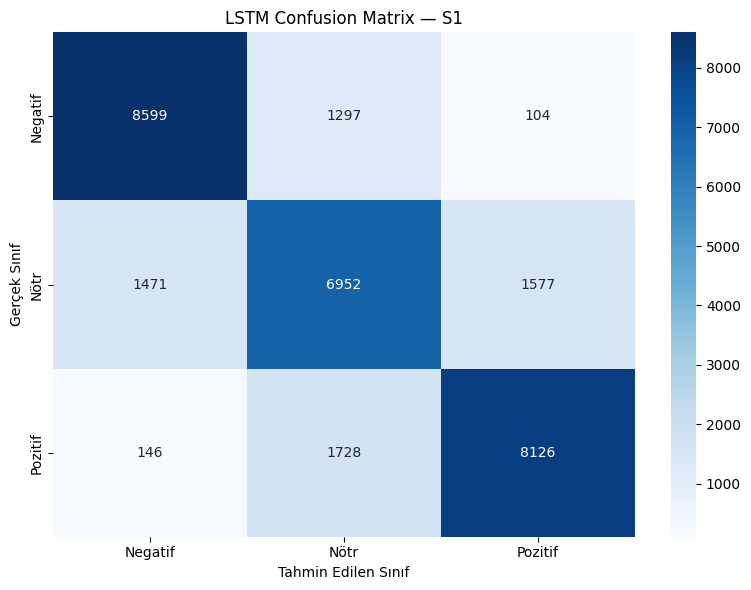


SENARYO: S2
Kelime kütüphanesi boyutu: 50000
Epoch  1 | Train Loss: 0.4166  Acc: 0.8456 | Val Loss: 0.3409  Acc: 0.8792
Epoch  2 | Train Loss: 0.3197  Acc: 0.8842 | Val Loss: 0.3214  Acc: 0.8848
Epoch  3 | Train Loss: 0.2768  Acc: 0.8987 | Val Loss: 0.3223  Acc: 0.8871
Epoch  4 | Train Loss: 0.2414  Acc: 0.9109 | Val Loss: 0.3293  Acc: 0.8893
Epoch  5 | Train Loss: 0.2051  Acc: 0.9243 | Val Loss: 0.3613  Acc: 0.8844
EarlyStopping: 5. epoch'ta durduruldu.
En iyi model yüklendi.


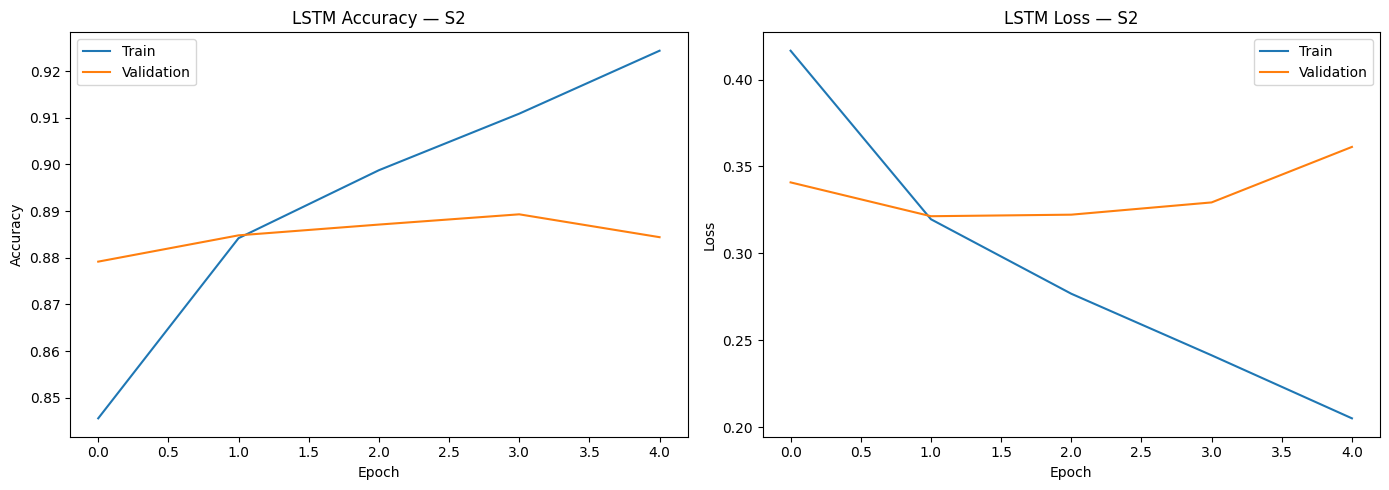


--- S2 | LSTM TEST SETİ PERFORMANSI ---
              precision    recall  f1-score   support

     Negatif       0.74      0.93      0.82     10000
        Nötr       0.94      0.26      0.41     10000
     Pozitif       0.66      0.97      0.79     10000

    accuracy                           0.72     30000
   macro avg       0.78      0.72      0.67     30000
weighted avg       0.78      0.72      0.67     30000



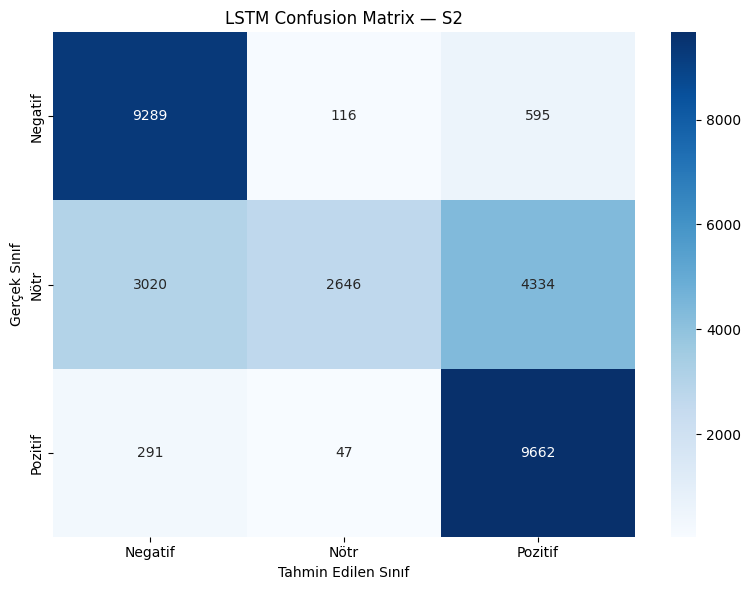


SENARYO: S3
Kelime kütüphanesi boyutu: 50000
Epoch  1 | Train Loss: 0.3067  Acc: 0.8901 | Val Loss: 0.2549  Acc: 0.9190
Epoch  2 | Train Loss: 0.2108  Acc: 0.9327 | Val Loss: 0.2195  Acc: 0.9323
Epoch  3 | Train Loss: 0.1742  Acc: 0.9453 | Val Loss: 0.2202  Acc: 0.9339
Epoch  4 | Train Loss: 0.1462  Acc: 0.9542 | Val Loss: 0.2277  Acc: 0.9346
Epoch  5 | Train Loss: 0.1198  Acc: 0.9619 | Val Loss: 0.2501  Acc: 0.9312
EarlyStopping: 5. epoch'ta durduruldu.
En iyi model yüklendi.


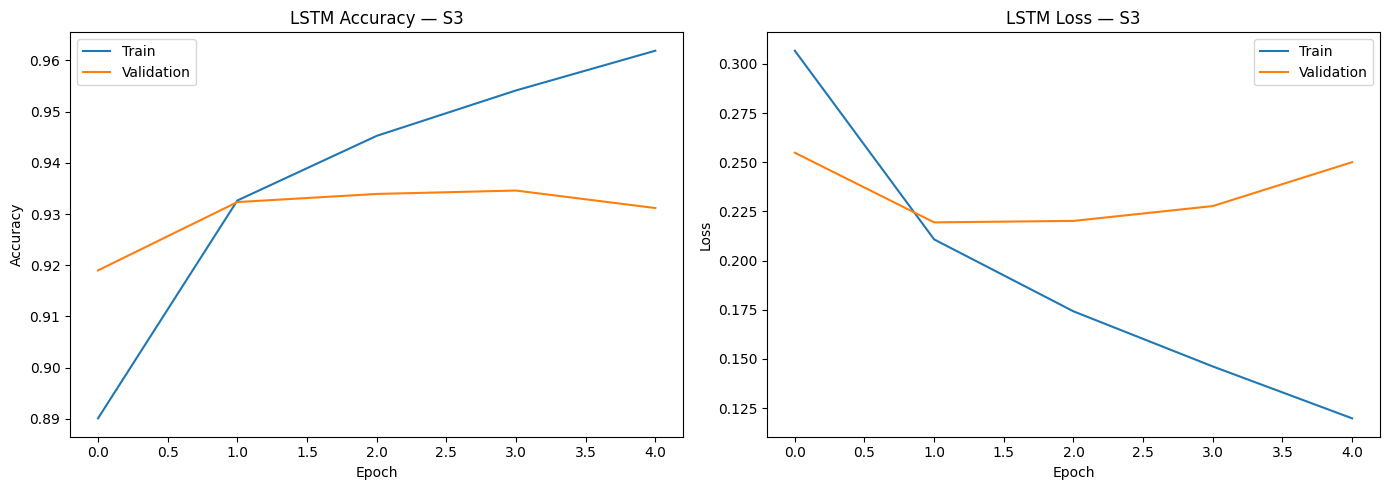


--- S3 | LSTM TEST SETİ PERFORMANSI ---
              precision    recall  f1-score   support

     Negatif       0.76      0.89      0.82     10000
        Nötr       0.98      0.23      0.37     10000
     Pozitif       0.61      0.98      0.76     10000

    accuracy                           0.70     30000
   macro avg       0.78      0.70      0.65     30000
weighted avg       0.78      0.70      0.65     30000



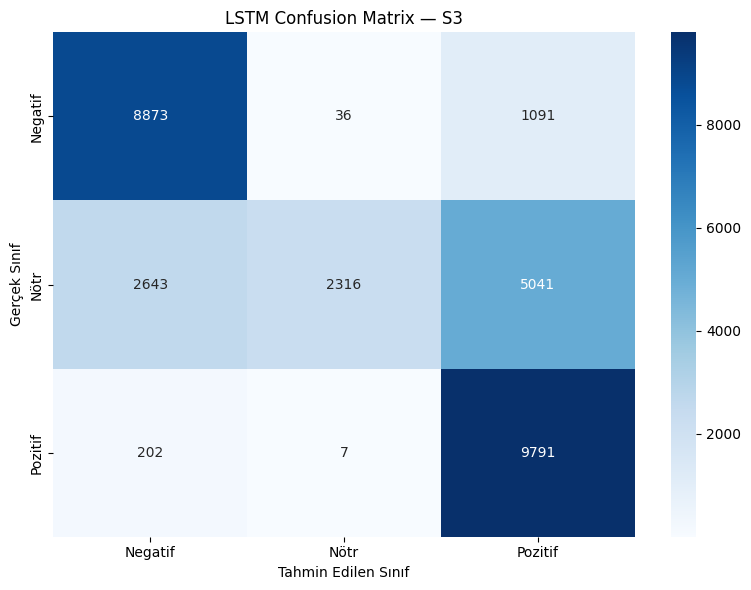


SENARYO: S4
Kelime kütüphanesi boyutu: 50000
Epoch  1 | Train Loss: 0.5298  Acc: 0.7532 | Val Loss: 0.4649  Acc: 0.7844
Epoch  2 | Train Loss: 0.4446  Acc: 0.7975 | Val Loss: 0.4483  Acc: 0.7930
Epoch  3 | Train Loss: 0.3973  Acc: 0.8224 | Val Loss: 0.4466  Acc: 0.7975
Epoch  4 | Train Loss: 0.3518  Acc: 0.8461 | Val Loss: 0.4692  Acc: 0.7930
Epoch  5 | Train Loss: 0.3020  Acc: 0.8709 | Val Loss: 0.4963  Acc: 0.7950
Epoch  6 | Train Loss: 0.2524  Acc: 0.8948 | Val Loss: 0.5213  Acc: 0.7985
EarlyStopping: 6. epoch'ta durduruldu.
En iyi model yüklendi.


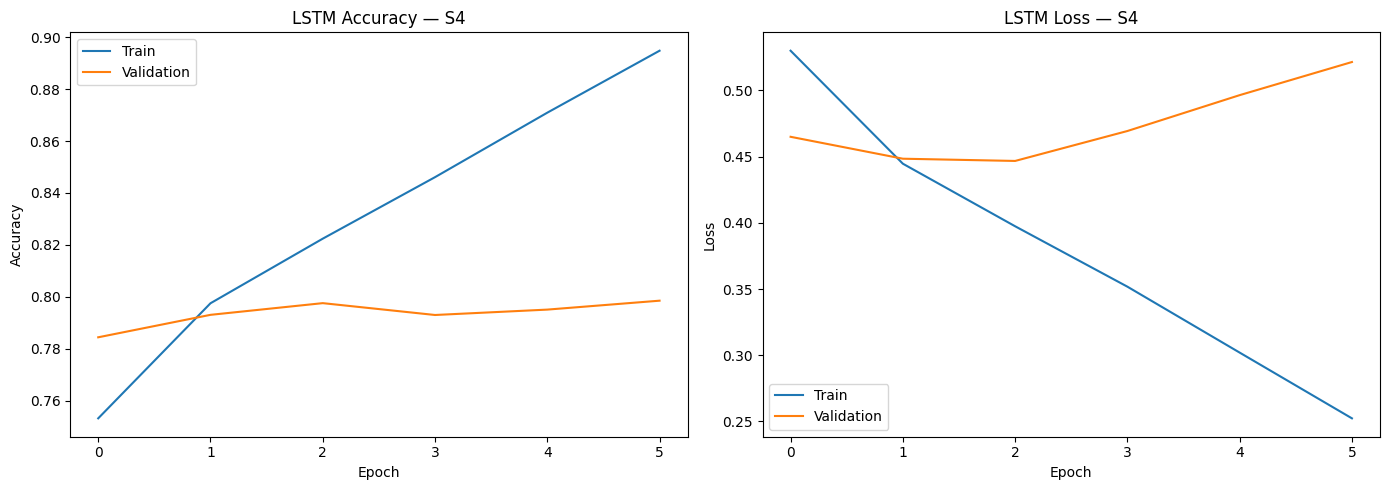


--- S4 | LSTM TEST SETİ PERFORMANSI ---
              precision    recall  f1-score   support

     Negatif       0.92      0.64      0.76     10000
        Nötr       0.62      0.72      0.67     10000
     Pozitif       0.77      0.88      0.82     10000

    accuracy                           0.75     30000
   macro avg       0.77      0.75      0.75     30000
weighted avg       0.77      0.75      0.75     30000



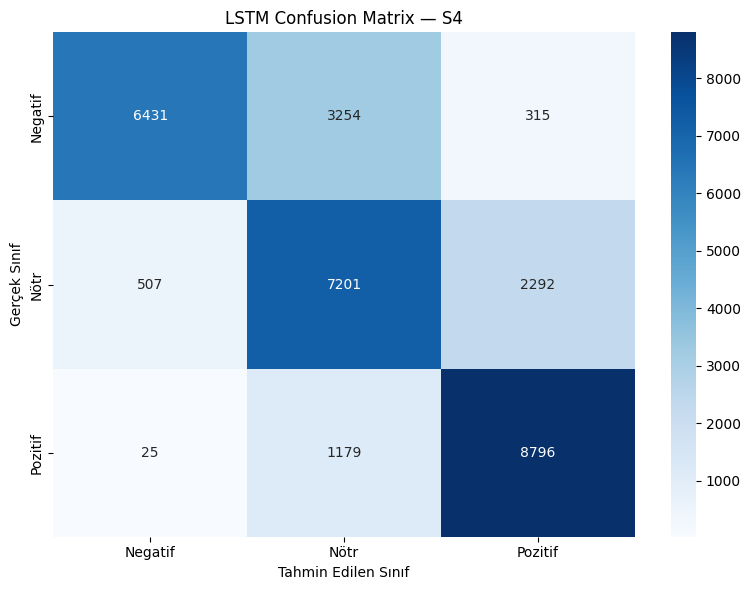

In [17]:
dl_results = {}

for name, data in scenario_data.items():
    print(f"\n{'='*50}")
    print(f"SENARYO: {name}")
    print(f"{'='*50}")

    lstm_model, lstm_preds = run_lstm(
        data['X_train_dl'], data['X_val_dl'],
        data['y_train'],    data['y_val'],
        best_params, name
    )

    dl_results[name] = {
        'lstm_model': lstm_model,
        'lstm_preds': lstm_preds
    }

## 8. Model Karşılaştırması ve Sonuç Tablosu

### 8.1 Macro-F1 ve Accuracy Karşılaştırma Tablosu

In [18]:
rows = []

for name in SCENARIOS.keys():
    nb_preds   = ml_results[name]['nb_preds']
    svm_preds  = ml_results[name]['svm_preds']
    lstm_preds = dl_results[name]['lstm_preds']

    for model_name, preds in [('NB', nb_preds), ('SVM', svm_preds), ('LSTM', lstm_preds)]:
        acc      = accuracy_score(y_test, preds)
        macro_f1 = f1_score(y_test, preds, average='macro')
        f1_neg   = f1_score(y_test, preds, average=None)[0]
        f1_ntr   = f1_score(y_test, preds, average=None)[1]
        f1_pos   = f1_score(y_test, preds, average=None)[2]

        rows.append({
            'Senaryo':     name,
            'Model':       model_name,
            'Accuracy':    round(acc,      4),
            'Macro-F1':    round(macro_f1, 4),
            'F1-Negatif':  round(f1_neg,   4),
            'F1-Nötr':     round(f1_ntr,   4),
            'F1-Pozitif':  round(f1_pos,   4),
        })

results_df = pd.DataFrame(rows)
display(results_df)

,Senaryo,Model,Accuracy,Macro-F1,F1-Negatif,F1-Nötr,F1-Pozitif
0,S1,NB,0.7591,0.7594,0.8239,0.6615,0.7927
1,S1,SVM,0.7805,0.7790,0.8447,0.6809,0.8115
2,S1,LSTM,0.7892,0.7891,0.8507,0.6960,0.8205
3,S2,NB,0.6942,0.6370,0.7871,0.3404,0.7834
4,S2,SVM,0.7250,0.6802,0.8205,0.4251,0.7950
5,S2,LSTM,0.7199,0.6737,0.8220,0.4131,0.7858
6,S3,NB,0.6655,0.5987,0.7915,0.2692,0.7354
7,S3,SVM,0.6990,0.6465,0.8267,0.3617,0.7512
8,S3,LSTM,0.6993,0.6491,0.8171,0.3748,0.7554
9,S4,NB,0.6759,0.6722,0.6181,0.6114,0.7870


### 8.2 Accuracy Paradox Gösterimi

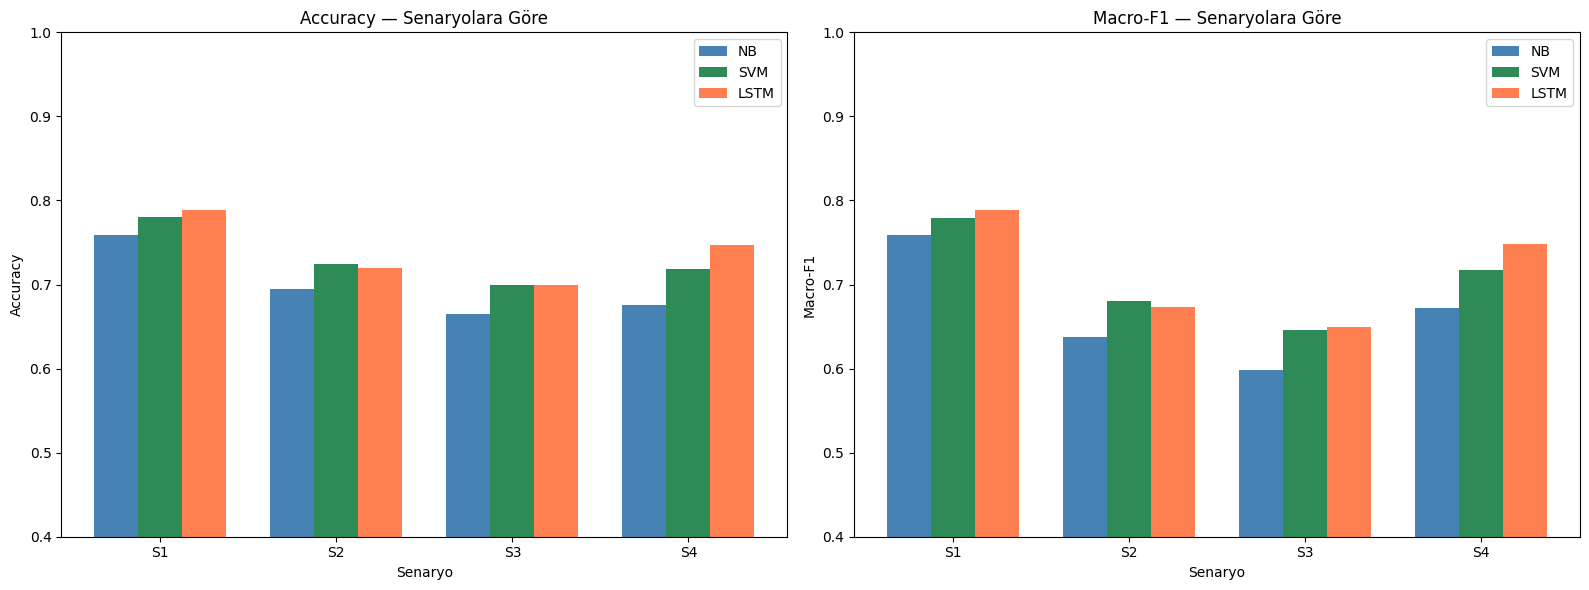

In [19]:
scenarios  = list(SCENARIOS.keys())
models     = ['NB', 'SVM', 'LSTM']
colors     = {'NB': 'steelblue', 'SVM': 'seagreen', 'LSTM': 'coral'}
x          = np.arange(len(scenarios))
width      = 0.25

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for i, model_name in enumerate(models):
    acc_vals = results_df[results_df['Model'] == model_name]['Accuracy'].values
    f1_vals  = results_df[results_df['Model'] == model_name]['Macro-F1'].values

    axes[0].bar(x + i * width, acc_vals, width, label=model_name, color=colors[model_name])
    axes[1].bar(x + i * width, f1_vals,  width, label=model_name, color=colors[model_name])

for ax, title, ylabel in zip(axes,
                              ['Accuracy — Senaryolara Göre', 'Macro-F1 — Senaryolara Göre'],
                              ['Accuracy', 'Macro-F1']):
    ax.set_xticks(x + width)
    ax.set_xticklabels(scenarios)
    ax.set_xlabel('Senaryo')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.set_ylim(0.4, 1.0)
    ax.legend()

plt.tight_layout()
plt.show()

### 8.3 Azınlık Sınıfı F1 Karşılaştırması

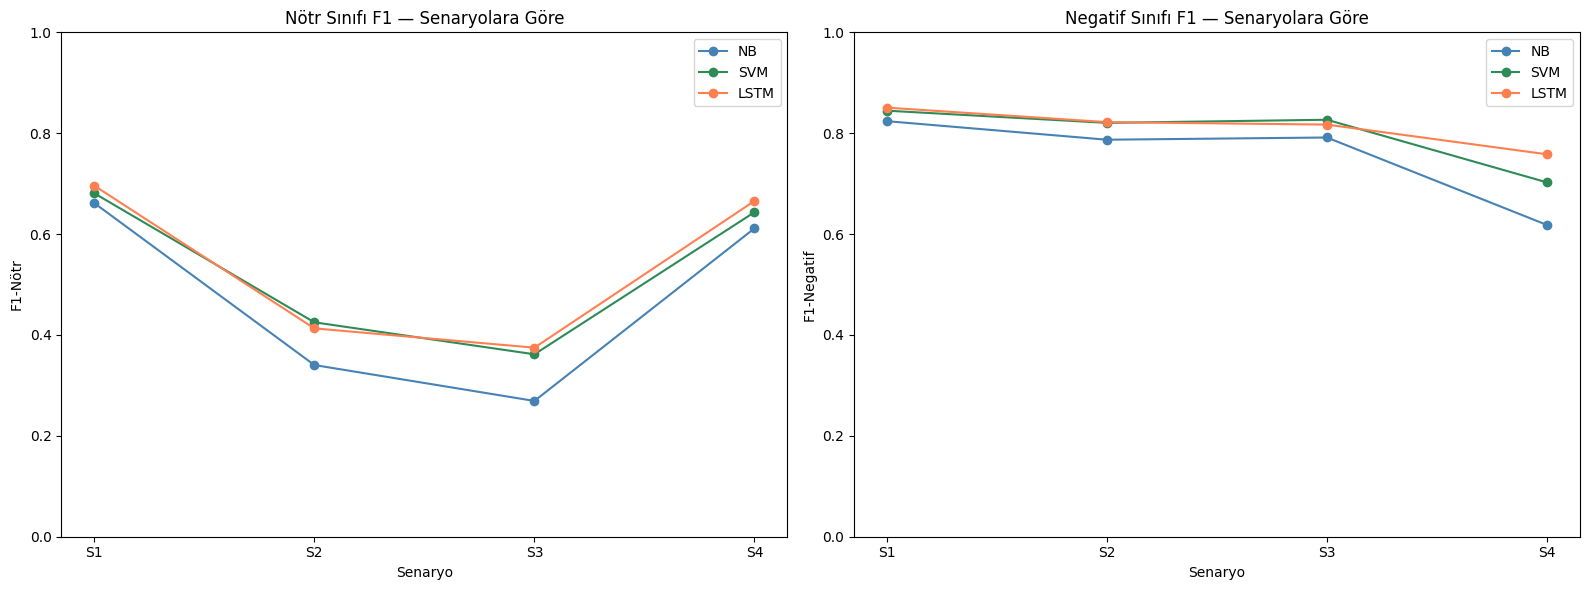

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for i, model_name in enumerate(models):
    df_m = results_df[results_df['Model'] == model_name]

    axes[0].plot(scenarios, df_m['F1-Nötr'].values,    marker='o', label=model_name, color=colors[model_name])
    axes[1].plot(scenarios, df_m['F1-Negatif'].values, marker='o', label=model_name, color=colors[model_name])

axes[0].set_title('Nötr Sınıfı F1 — Senaryolara Göre')
axes[0].set_xlabel('Senaryo')
axes[0].set_ylabel('F1-Nötr')
axes[0].set_ylim(0.0, 1.0)
axes[0].legend()

axes[1].set_title('Negatif Sınıfı F1 — Senaryolara Göre')
axes[1].set_xlabel('Senaryo')
axes[1].set_ylabel('F1-Negatif')
axes[1].set_ylim(0.0, 1.0)
axes[1].legend()

plt.tight_layout()
plt.show()

### 8.4 Accuracy ve Macro-F1 Farkı (Accuracy Paradox Analizi)

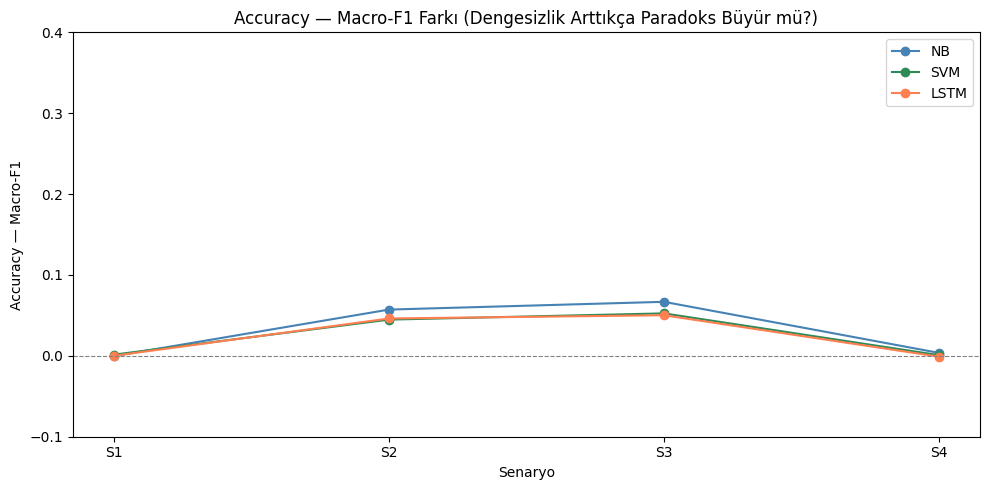


Sonuç Tablosu:


,Senaryo,Model,Accuracy,Macro-F1,Acc-F1 Farkı
0,S1,NB,0.7591,0.7594,-0.0003
1,S1,SVM,0.7805,0.7790,0.0015
2,S1,LSTM,0.7892,0.7891,0.0001
3,S2,NB,0.6942,0.6370,0.0572
4,S2,SVM,0.7250,0.6802,0.0448
5,S2,LSTM,0.7199,0.6737,0.0462
6,S3,NB,0.6655,0.5987,0.0668
7,S3,SVM,0.6990,0.6465,0.0525
8,S3,LSTM,0.6993,0.6491,0.0502
9,S4,NB,0.6759,0.6722,0.0037


In [21]:
results_df['Acc-F1 Farkı'] = (results_df['Accuracy'] - results_df['Macro-F1']).round(4)

fig, ax = plt.subplots(figsize=(10, 5))

for i, model_name in enumerate(models):
    df_m = results_df[results_df['Model'] == model_name]
    ax.plot(scenarios, df_m['Acc-F1 Farkı'].values, marker='o', label=model_name, color=colors[model_name])

ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.8)
ax.set_title('Accuracy — Macro-F1 Farkı (Dengesizlik Arttıkça Paradoks Büyür mü?)')
ax.set_xlabel('Senaryo')
ax.set_ylabel('Accuracy — Macro-F1')
ax.set_ylim(-0.1, 0.4)
ax.legend()

plt.tight_layout()
plt.show()

print("\nSonuç Tablosu:")
display(results_df[['Senaryo', 'Model', 'Accuracy', 'Macro-F1', 'Acc-F1 Farkı']])